In [ ]:
from pathlib import Path

DATA_DIR = Path('/kaggle/input/datasets/balraj98/deepglobe-land-cover-classification-dataset')

for split in ['train', 'valid', 'test']:
    imgs = list((DATA_DIR / split).glob('*_sat.jpg'))
    masks = list((DATA_DIR / split).glob('*_mask.png'))
    print(f'  {split}: {len(imgs)} images, {len(masks)} masks')

print('\nDeepGlobe dataset ready.')

In [ ]:
import os, sys
CODE_DIR = '/kaggle/working/code'
os.makedirs(CODE_DIR, exist_ok=True)
os.makedirs(f'{CODE_DIR}/task1_crop/models', exist_ok=True)
os.makedirs(f'{CODE_DIR}/task1_crop/utils', exist_ok=True)
os.makedirs(f'{CODE_DIR}/task1_crop/data', exist_ok=True)
sys.path.insert(0, CODE_DIR)
print(f'Code dir: {CODE_DIR}')

In [ ]:
%%writefile /kaggle/working/code/task1_crop/utils/preprocessing.py
"""
Preprocessing pipeline for DeepGlobe Land Cover dataset.
Valid/test splits have no masks — we carve our own val from train (80/20).
"""

from pathlib import Path
from typing import Tuple, List
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import albumentations as A
from albumentations.pytorch import ToTensorV2

TILE_SIZE   = 512
NUM_CLASSES = 7
MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

CLASS_NAMES = [
    'urban_land', 'agriculture', 'rangeland',
    'forest', 'water', 'barren_land', 'unknown'
]

COLOUR_MAP = {
    (0,   255, 255): 0,  # urban_land
    (255, 255,   0): 1,  # agriculture
    (255,   0, 255): 2,  # rangeland
    (0,   255,   0): 3,  # forest
    (0,     0, 255): 4,  # water
    (255, 255, 255): 5,  # barren_land
    (0,     0,   0): 6,  # unknown
}

_LUT = np.full(256**3, 6, dtype=np.uint8)
for (r, g, b), idx in COLOUR_MAP.items():
    _LUT[r * 65536 + g * 256 + b] = idx


def decode_mask(mask_path: str) -> np.ndarray:
    arr = np.array(Image.open(mask_path).convert('RGB'))
    key = (arr[:, :, 0].astype(np.int32) * 65536
         + arr[:, :, 1].astype(np.int32) * 256
         + arr[:, :, 2].astype(np.int32))
    return _LUT[key]


class DeepGlobeDataset(Dataset):
    def __init__(self, image_paths: List[Path], transform=None):
        self.images    = image_paths
        self.transform = transform
        assert len(self.images) > 0, 'No images found'

    def __len__(self): return len(self.images)

    def __getitem__(self, idx):
        img_path  = self.images[idx]
        mask_path = str(img_path).replace('_sat.jpg', '_mask.png')

        image = np.array(Image.open(img_path).convert('RGB'))
        mask  = decode_mask(mask_path)

        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image, mask = augmented['image'], augmented['mask']

        return image, mask.long()


def build_transforms(split: str) -> A.Compose:
    if split == 'train':
        return A.Compose([
            A.RandomCrop(TILE_SIZE, TILE_SIZE),
            A.HorizontalFlip(p=0.5),
            A.VerticalFlip(p=0.5),
            A.RandomRotate90(p=0.5),
            A.ColorJitter(brightness=0.2, contrast=0.2,
                          saturation=0.2, hue=0.1, p=0.5),
            A.Normalize(mean=MEAN, std=STD),
            ToTensorV2(),
        ])
    return A.Compose([
        A.CenterCrop(TILE_SIZE, TILE_SIZE),
        A.Normalize(mean=MEAN, std=STD),
        ToTensorV2(),
    ])


def build_dataloaders(data_root: str, batch_size: int = 8,
                      num_workers: int = 2,
                      val_split: float = 0.2,
                      seed: int = 42) -> Tuple[DataLoader, DataLoader]:

    all_images = sorted(Path(data_root, 'train').glob('*_sat.jpg'))
    assert len(all_images) > 0, f'No training images found in {data_root}/train'

    # Deterministic 80/20 split
    rng = np.random.default_rng(seed)
    indices = rng.permutation(len(all_images))
    split_at = int(len(all_images) * (1 - val_split))
    train_paths = [all_images[i] for i in indices[:split_at]]
    val_paths   = [all_images[i] for i in indices[split_at:]]

    train_ds = DeepGlobeDataset(train_paths, build_transforms('train'))
    val_ds   = DeepGlobeDataset(val_paths,   build_transforms('val'))

    train_dl = DataLoader(train_ds, batch_size=batch_size, shuffle=True,
                          num_workers=num_workers, pin_memory=True,
                          persistent_workers=num_workers > 0)
    val_dl   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False,
                          num_workers=num_workers, pin_memory=True,
                          persistent_workers=num_workers > 0)

    print(f'Train: {len(train_ds)} samples | Val: {len(val_ds)} samples')
    return train_dl, val_dl

Writing /kaggle/working/code/task1_crop/utils/preprocessing.py


In [ ]:
%%writefile /kaggle/working/code/task1_crop/models/segformer_trainer.py
"""
SegFormer-B2 trainer for DeepGlobe (7 classes).
"""
import os, sys, time, json
from pathlib import Path
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.cuda.amp import GradScaler, autocast
from transformers import SegformerForSemanticSegmentation
sys.path.insert(0, '/kaggle/working/code')
from task1_crop.utils.preprocessing import NUM_CLASSES, build_dataloaders

def build_segformer(num_classes=NUM_CLASSES,
                    variant='nvidia/segformer-b2-finetuned-ade-512-512'):
    return SegformerForSemanticSegmentation.from_pretrained(
        variant, num_labels=num_classes, ignore_mismatched_sizes=True)


class CombinedLoss(nn.Module):
    def __init__(self, class_weights=None, dice_weight=0.5):
        super().__init__()
        self.dice_weight = dice_weight
        self.ce = nn.CrossEntropyLoss(weight=class_weights, ignore_index=6)

    def dice_loss(self, logits, targets):
        probs   = torch.softmax(logits, dim=1)
        n, c    = probs.shape[:2]
        valid   = (targets != 6).unsqueeze(1).float()
        one_hot = torch.zeros_like(probs).scatter_(
            1, targets.unsqueeze(1).clamp(0, c-1), 1) * valid
        probs   = probs * valid
        inter   = (probs * one_hot).sum(dim=(2, 3))
        union   = probs.sum(dim=(2, 3)) + one_hot.sum(dim=(2, 3))
        dice    = 1 - (2 * inter + 1) / (union + 1)
        return dice[:, :6].mean()  # exclude unknown class column

    def forward(self, logits, targets):
        return (1 - self.dice_weight) * self.ce(logits, targets) \
               + self.dice_weight * self.dice_loss(logits, targets)


def compute_miou(preds, targets, num_classes=NUM_CLASSES, ignore_index=6):
    ious = []
    preds   = preds.cpu().numpy().flatten()
    targets = targets.cpu().numpy().flatten()
    for c in range(num_classes):
        if c == ignore_index: continue
        tp = ((preds == c) & (targets == c)).sum()
        fp = ((preds == c) & (targets != c)).sum()
        fn = ((preds != c) & (targets == c)).sum()
        if tp + fp + fn == 0: continue
        ious.append(tp / (tp + fp + fn))
    return float(np.mean(ious)) if ious else 0.0


def train(data_root, output_dir, epochs=30, batch_size=8, lr=6e-5,
          class_weights_path=None, resume=None):

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f'Device: {device}')
    Path(output_dir).mkdir(parents=True, exist_ok=True)

    train_dl, val_dl = build_dataloaders(data_root, batch_size)

    model = build_segformer().to(device)

    weights = None
    if class_weights_path and os.path.exists(class_weights_path):
        weights = torch.tensor(np.load(class_weights_path),
                               dtype=torch.float32).to(device)
        print(f'Class weights loaded: {weights.cpu().numpy().round(3)}')

    criterion = CombinedLoss(class_weights=weights)
    optimizer = optim.AdamW(model.parameters(), lr=2e-5, weight_decay=0.01)

    def lr_lambda(epoch):
        warmup = 5
        if epoch < warmup:
            return (epoch + 1) / warmup
        progress = (epoch - warmup) / max(1, epochs - warmup)
        return 0.5 * (1 + np.cos(np.pi * progress))

    scheduler = optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)
    scaler    = GradScaler()

    start_epoch, best_miou = 0, 0.0
    if resume and os.path.exists(resume):
        ckpt = torch.load(resume, map_location=device)
        model.load_state_dict(ckpt['model'])
        optimizer.load_state_dict(ckpt['optimizer'])
        for pg in optimizer.param_groups:
            pg['lr'] = lr
        start_epoch = ckpt['epoch'] + 1
        best_miou   = ckpt.get('best_miou', 0.0)
        print(f'Resumed from epoch {start_epoch}, best mIoU {best_miou:.4f}, lr reset to {lr}')

    history = []
    for epoch in range(start_epoch, epochs):
        model.train()
        t0 = time.time()
        train_loss = 0.0
        for imgs, masks in train_dl:
            imgs, masks = imgs.to(device), masks.to(device)
            optimizer.zero_grad()
            with autocast():
                out    = model(pixel_values=imgs)
                logits = nn.functional.interpolate(
                    out.logits, size=masks.shape[-2:], mode='bilinear',
                    align_corners=False)
                loss = criterion(logits, masks)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            train_loss += loss.item()
        model.eval()
        val_loss, all_preds, all_masks = 0.0, [], []
        with torch.no_grad():
            for imgs, masks in val_dl:
                imgs, masks = imgs.to(device), masks.to(device)
                with autocast():
                    out    = model(pixel_values=imgs)
                    logits = nn.functional.interpolate(
                        out.logits, size=masks.shape[-2:],
                        mode='bilinear', align_corners=False)
                    loss = criterion(logits, masks)
                val_loss += loss.item()
                all_preds.append(logits.argmax(dim=1).cpu())
                all_masks.append(masks.cpu())
        all_preds = torch.cat(all_preds)
        all_masks = torch.cat(all_masks)
        val_miou  = compute_miou(all_preds, all_masks)
        vl = val_loss / len(val_dl)

        n_train = len(train_dl)
        n_val   = len(val_dl)
        tl = train_loss / n_train
        vl = val_loss   / n_val
        vm = val_miou   / n_val
        scheduler.step()

        elapsed = time.time() - t0
        print(f'Epoch {epoch+1:02d}/{epochs} | '
              f'train_loss {tl:.4f} | val_loss {vl:.4f} | '
              f'val_mIoU {vm:.4f} | {elapsed:.0f}s')

        history.append({'epoch': epoch+1, 'train_loss': tl,
                         'val_loss': vl, 'val_miou': vm})
        ckpt = {'epoch': epoch, 'model': model.state_dict(),
                'optimizer': optimizer.state_dict(), 'best_miou': best_miou}
        torch.save(ckpt, f'{output_dir}/last.pt')
        if vm > best_miou:
            best_miou = vm
            torch.save(ckpt, f'{output_dir}/best.pt')
            print(f'New best mIoU: {best_miou:.4f}')

    with open(f'{output_dir}/history.json', 'w') as f:
        json.dump(history, f, indent=2)
    print(f'\nTraining complete. Best mIoU: {best_miou:.4f}')
    print(f'Checkpoint: {output_dir}/best.pt')

Writing /kaggle/working/code/task1_crop/models/segformer_trainer.py


FileNotFoundError: [Errno 2] No such file or directory: '/kaggle/working/code/task1_crop/models/segformer_trainer.py'

In [ ]:
import numpy as np, os
from pathlib import Path
from PIL import Image

DATA_DIR     = '/kaggle/input/datasets/balraj98/deepglobe-land-cover-classification-dataset'
WEIGHTS_PATH = '/kaggle/working/class_weights.npy'
NUM_CLASSES  = 7

COLOUR_MAP = {
    (0,   255, 255): 0,  # urban_land
    (255, 255,   0): 1,  # agriculture
    (255,   0, 255): 2,  # rangeland
    (0,   255,   0): 3,  # forest
    (0,     0, 255): 4,  # water
    (255, 255, 255): 5,  # barren_land
    (0,     0,   0): 6,  # unknown
}

def rgb_to_key(arr):
    """(H,W,3) uint8 → (H,W) int32 packed key"""
    return arr[:,:,0].astype(np.int32)*65536 \
         + arr[:,:,1].astype(np.int32)*256 \
         + arr[:,:,2].astype(np.int32)

# Build vectorized lookup table
lut = np.full(256**3, 6, dtype=np.uint8)  
for (r,g,b), idx in COLOUR_MAP.items():
    lut[r*65536 + g*256 + b] = idx

def decode_mask_fast(mask_path):
    arr = np.array(Image.open(mask_path).convert('RGB'))
    return lut[rgb_to_key(arr)]

if os.path.exists(WEIGHTS_PATH):
    weights = np.load(WEIGHTS_PATH)
    print('Already computed.')
else:
    masks  = sorted(Path(f'{DATA_DIR}/train').glob('*_mask.png'))
    counts = np.zeros(NUM_CLASSES, dtype=np.int64)
    print(f'Computing from {len(masks)} masks...')
    for i, mp in enumerate(masks):
        flat = decode_mask_fast(str(mp)).ravel()
        for c in range(NUM_CLASSES):
            counts[c] += (flat == c).sum()
        if i % 100 == 0:
            print(f'  {i}/{len(masks)}', end='\r')
    total   = counts.sum()
    weights = total / (NUM_CLASSES * np.maximum(counts, 1))
    weights = weights / weights.sum()
    np.save(WEIGHTS_PATH, weights)

CLASS_NAMES = ['urban_land','agriculture','rangeland',
               'forest','water','barren_land','unknown']
for n, w in zip(CLASS_NAMES, weights):
    print(f'  {n:<20} {w:.4f}')
print('\n✓ Class weights saved.')

In [ ]:
weights = np.load('/kaggle/working/class_weights.npy')
weights[6] = 0.0          # zero out unknown
weights = weights / weights[:6].sum()  
np.save('/kaggle/working/class_weights.npy', weights)

CLASS_NAMES = ['urban_land','agriculture','rangeland','forest','water','barren_land','unknown']
for n, w in zip(CLASS_NAMES, weights):
    print(f'  {n:<20} {w:.4f}')

In [ ]:
import sys
sys.path.insert(0, '/kaggle/working/code')
from task1_crop.models.segformer_trainer import train

OUTPUT_DIR = '/kaggle/working/outputs/task1_model'

train(
    data_root          = '/kaggle/input/datasets/balraj98/deepglobe-land-cover-classification-dataset',
    output_dir         = OUTPUT_DIR,
    epochs             = 60,
    batch_size         = 8,
    lr                 = 2e-5,       
    class_weights_path = '/kaggle/working/class_weights.npy',
    resume             = '/kaggle/working/outputs/task1_model/best.pt', 
)

In [ ]:
%%writefile /kaggle/working/code/task1_crop/inference.py
import json, warnings
from pathlib import Path
from typing import Optional
import numpy as np
import torch
import torch.nn.functional as F
from PIL import Image
import rasterio
from rasterio.transform import from_bounds
from rasterio.features import shapes
from rasterio import MemoryFile
from shapely.geometry import shape, mapping
from shapely.ops import unary_union
import albumentations as A
from albumentations.pytorch import ToTensorV2
from transformers import SegformerForSemanticSegmentation

TILE_SIZE   = 512
OVERLAP     = 64
NUM_CLASSES = 7
MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

CLASS_NAMES = [
    'urban_land', 'agriculture', 'rangeland',
    'forest', 'water', 'barren_land', 'unknown'
]

DEFAULT_BBOX = (-93.525, 41.475, -93.475, 41.525)  


def load_model(checkpoint_path: str, device: torch.device):
    model = SegformerForSemanticSegmentation.from_pretrained(
        'nvidia/segformer-b2-finetuned-ade-512-512',
        num_labels=NUM_CLASSES,
        ignore_mismatched_sizes=True
    )
    ckpt = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(ckpt['model'])
    model.to(device).eval()
    return model


def preprocess():
    return A.Compose([
        A.Normalize(mean=MEAN, std=STD),
        ToTensorV2(),
    ])


def predict_full_image(model, image: np.ndarray,
                       device: torch.device,
                       tile_size: int = TILE_SIZE,
                       overlap: int = OVERLAP) -> np.ndarray:
    """
    Tile the image with overlap, run inference on each tile,
    stitch back via probability averaging in overlap zones.
    Returns (H, W) int array of class indices.
    """
    H, W    = image.shape[:2]
    tf      = preprocess()
    stride  = tile_size - overlap

    
    prob_sum = np.zeros((NUM_CLASSES, H, W), dtype=np.float32)
    count    = np.zeros((H, W), dtype=np.float32)

    rows = list(range(0, H - tile_size + 1, stride))
    cols = list(range(0, W - tile_size + 1, stride))
    if rows[-1] + tile_size < H: rows.append(H - tile_size)
    if cols[-1] + tile_size < W: cols.append(W - tile_size)

    with torch.no_grad():
        for r in rows:
            for c in cols:
                tile = image[r:r+tile_size, c:c+tile_size]
                inp  = tf(image=tile)['image'].unsqueeze(0).to(device)
                out  = model(pixel_values=inp)
                logits = F.interpolate(out.logits,
                                       size=(tile_size, tile_size),
                                       mode='bilinear', align_corners=False)
                probs = torch.softmax(logits, dim=1).squeeze(0).cpu().numpy()
                prob_sum[:, r:r+tile_size, c:c+tile_size] += probs
                count[r:r+tile_size, c:c+tile_size] += 1

    
    count = np.maximum(count, 1)
    avg_probs = prob_sum / count[np.newaxis]
    return avg_probs.argmax(axis=0).astype(np.uint8), avg_probs


def compute_health_index(image: np.ndarray, mask: np.ndarray,
                          class_idx: int) -> float:
    pixels = image[mask == class_idx].astype(np.float32)
    if len(pixels) < 10:
        return 0.0
    R, G, B = pixels[:, 0], pixels[:, 1], pixels[:, 2]
    denom = (G + R - B)
    valid = np.abs(denom) > 1e-6
    if valid.sum() < 5:
        return 0.0
    vari = (G[valid] - R[valid]) / denom[valid]
    vari = np.clip(vari, -1, 1)
    return float(np.mean(vari))


def mask_to_geojson(mask: np.ndarray,
                    avg_probs: np.ndarray,
                    image: np.ndarray,
                    bbox: tuple,
                    min_area_px: int = 500) -> dict:
    H, W = mask.shape
    min_lon, min_lat, max_lon, max_lat = bbox

    transform = from_bounds(min_lon, min_lat, max_lon, max_lat, W, H)

    features = []
    for class_idx in range(NUM_CLASSES - 1):  # skip 'unknown'
        class_mask = (mask == class_idx).astype(np.uint8)
        if class_mask.sum() < min_area_px:
            continue

        
        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            polys = list(shapes(class_mask, mask=class_mask,
                                transform=transform))

        for geom_dict, val in polys:
            if val == 0:
                continue
            geom = shape(geom_dict)
            if geom.area < 1e-8:
                continue

            
            minx, miny, maxx, maxy = geom.bounds
            
            px_c1 = max(0, int((minx - min_lon) / (max_lon - min_lon) * W))
            px_c2 = min(W, int((maxx - min_lon) / (max_lon - min_lon) * W))
            px_r1 = max(0, int((max_lat - maxy) / (max_lat - min_lat) * H))
            px_r2 = min(H, int((max_lat - miny) / (max_lat - min_lat) * H))

            region_mask  = mask[px_r1:px_r2, px_c1:px_c2] == class_idx
            region_probs = avg_probs[class_idx, px_r1:px_r2, px_c1:px_c2]
            confidence   = float(region_probs[region_mask].mean()) if region_mask.any() else 0.0

            health = compute_health_index(image, mask, class_idx)

            feature = {
                'type': 'Feature',
                'geometry': mapping(geom),
                'properties': {
                    'crop_type':    CLASS_NAMES[class_idx],
                    'confidence':   round(confidence, 4),
                    'health_index': round(health, 4),
                    'bbox_latlon':  [round(x, 6) for x in [minx, miny, maxx, maxy]],
                    'area_deg2':    round(geom.area, 10),
                }
            }
            features.append(feature)

    return {
        'type': 'FeatureCollection',
        'features': features,
        'metadata': {
            'num_classes': NUM_CLASSES - 1,
            'class_names': CLASS_NAMES[:-1],
            'bbox_wgs84': list(bbox),
            'image_size': [H, W],
        }
    }


def run_inference(image_path: str,
                  checkpoint_path: str,
                  output_path: str,
                  bbox: Optional[tuple] = None):

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f'Device: {device}')

    print('Loading model...')
    model = load_model(checkpoint_path, device)

    print(f'Loading image: {image_path}')
    image = np.array(Image.open(image_path).convert('RGB'))
    H, W  = image.shape[:2]
    print(f'Image size: {H}×{W}')

    if bbox is None:
        bbox = DEFAULT_BBOX
        print(f'No geo metadata — using synthetic bbox: {bbox}')

    print('Running tiled inference...')
    mask, avg_probs = predict_full_image(model, image, device)

    print('Predicted class distribution:')
    for i, name in enumerate(CLASS_NAMES):
        pct = (mask == i).sum() / mask.size * 100
        print(f'  {name:<20} {pct:.1f}%')

    print('Polygonizing...')
    geojson = mask_to_geojson(mask, avg_probs, image, bbox)
    print(f'Generated {len(geojson["features"])} polygons')

    Path(output_path).parent.mkdir(parents=True, exist_ok=True)
    with open(output_path, 'w') as f:
        json.dump(geojson, f, indent=2)
    print(f'Saved GeoJSON → {output_path}')

    return mask, geojson

Writing /kaggle/working/code/task1_crop/inference.py


In [ ]:
import sys
sys.path.insert(0, '/kaggle/working/code')
from task1_crop.inference import run_inference
from pathlib import Path
import json

DATA_DIR   = '/kaggle/input/datasets/balraj98/deepglobe-land-cover-classification-dataset'
CKPT       = '/kaggle/input/models/manishsabnis/deepglobe-land-cover-best/pytorch/default/1/best.pt'
OUT_DIR    = '/kaggle/working/outputs/geojson'

test_images = sorted(Path(f'{DATA_DIR}/test').glob('*_sat.jpg'))[:5]

base_lon, base_lat = -93.525, 41.475
step = 0.06

all_results = []
for i, img_path in enumerate(test_images):
    bbox = (
        base_lon + i * step,
        base_lat,
        base_lon + i * step + 0.05,
        base_lat + 0.05
    )
    out_path = f'{OUT_DIR}/{img_path.stem}.geojson'
    print(f'\n=== Image {i+1}/5: {img_path.name} ===')
    mask, geojson = run_inference(str(img_path), CKPT, out_path, bbox=bbox)
    all_results.append((img_path.name, geojson))

combined = {
    'type': 'FeatureCollection',
    'features': [f for _, gj in all_results for f in gj['features']]
}
with open(f'{OUT_DIR}/combined_5_images.geojson', 'w') as f:
    json.dump(combined, f, indent=2)

print(f'\n✓ Combined GeoJSON: {len(combined["features"])} total polygons')
print(f'Saved to {OUT_DIR}/combined_5_images.geojson')


=== Image 1/5: 100877_sat.jpg ===
Device: cuda
Loading model...


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/110M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/380 [00:00<?, ?it/s]

SegformerForSemanticSegmentation LOAD REPORT from: nvidia/segformer-b2-finetuned-ade-512-512
Key                           | Status   |                                                                                                   
------------------------------+----------+---------------------------------------------------------------------------------------------------
decode_head.classifier.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([150, 768, 1, 1]) vs model:torch.Size([7, 768, 1, 1])
decode_head.classifier.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([150]) vs model:torch.Size([7])                      

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


...

SegformerForSemanticSegmentation LOAD REPORT from: nvidia/segformer-b2-finetuned-ade-512-512
Key                           | Status   |                                                                                                   
------------------------------+----------+---------------------------------------------------------------------------------------------------
decode_head.classifier.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([150, 768, 1, 1]) vs model:torch.Size([7, 768, 1, 1])
decode_head.classifier.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([150]) vs model:torch.Size([7])                      

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


Loading image: /kaggle/input/datasets/balraj98/deepglobe-land-cover-classification-dataset/test/110224_sat.jpg
Image size: 2448×2448
Running tiled inference...
Predicted class distribution:
  urban_land           1.7%
  agriculture          89.2%
  rangeland            6.1%
  forest               2.0%
  water                0.7%
  barren_land          0.3%
  unknown              0.0%
Polygonizing...
Generated 74 polygons
Saved GeoJSON → /kaggle/working/outputs/geojson/110224_sat.geojson

=== Image 5/5: 112946_sat.jpg ===
Device: cuda
Loading model...


Loading weights:   0%|          | 0/380 [00:00<?, ?it/s]

SegformerForSemanticSegmentation LOAD REPORT from: nvidia/segformer-b2-finetuned-ade-512-512
Key                           | Status   |                                                                                                   
------------------------------+----------+---------------------------------------------------------------------------------------------------
decode_head.classifier.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([150, 768, 1, 1]) vs model:torch.Size([7, 768, 1, 1])
decode_head.classifier.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([150]) vs model:torch.Size([7])                      

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


Loading image: /kaggle/input/datasets/balraj98/deepglobe-land-cover-classification-dataset/test/112946_sat.jpg
Image size: 2448×2448
Running tiled inference...
Predicted class distribution:
  urban_land           0.0%
  agriculture          48.0%
  rangeland            4.8%
  forest               0.0%
  water                23.3%
  barren_land          23.9%
  unknown              0.0%
Polygonizing...
Generated 32 polygons
Saved GeoJSON → /kaggle/working/outputs/geojson/112946_sat.geojson

✓ Combined GeoJSON: 400 total polygons
Saved to /kaggle/working/outputs/geojson/combined_5_images.geojson


In [ ]:
import sys, numpy as np
sys.path.insert(0, '/kaggle/working/code')
from task1_crop.inference import load_model, preprocess, predict_full_image, CLASS_NAMES, NUM_CLASSES
from task1_crop.utils.preprocessing import decode_mask
from pathlib import Path
from sklearn.metrics import f1_score, average_precision_score
import torch
from PIL import Image

DATA_DIR = '/kaggle/input/datasets/balraj98/deepglobe-land-cover-classification-dataset'
CKPT     = '/kaggle/input/models/manishsabnis/deepglobe-land-cover-best/pytorch/default/1/best.pt'

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model  = load_model(CKPT, device)

all_images = sorted(Path(f'{DATA_DIR}/train').glob('*_sat.jpg'))
rng        = np.random.default_rng(42)
indices    = rng.permutation(len(all_images))
val_paths  = [all_images[i] for i in indices[int(len(all_images)*0.8):]]

print(f'Evaluating on {len(val_paths)} val images...')

all_preds, all_labels = [], []

for img_path in val_paths:
    mask_path = str(img_path).replace('_sat.jpg', '_mask.png')
    image = np.array(Image.open(img_path).convert('RGB'))
    gt    = decode_mask(mask_path).flatten()

    pred, _ = predict_full_image(model, image, device)
    all_preds.append(pred.flatten())
    all_labels.append(gt)

all_preds  = np.concatenate(all_preds)
all_labels = np.concatenate(all_labels)


valid = all_labels != 6
preds_v  = all_preds[valid]
labels_v = all_labels[valid]

print('\n', '──', 'Per-class metrics', '─'*40)
print(f'{"Class":<20} {"IoU":>8} {"F1":>8} {"Support":>10}')
print('─'*50)

ious, f1s = [], []
for c in range(NUM_CLASSES - 1):
    tp = ((preds_v == c) & (labels_v == c)).sum()
    fp = ((preds_v == c) & (labels_v != c)).sum()
    fn = ((preds_v != c) & (labels_v == c)).sum()
    iou = tp / (tp + fp + fn + 1e-8)
    f1  = 2*tp / (2*tp + fp + fn + 1e-8)
    sup = (labels_v == c).sum()
    ious.append(iou)
    f1s.append(f1)
    print(f'{CLASS_NAMES[c]:<20} {iou:>8.4f} {f1:>8.4f} {sup:>10,}')

print('─'*50)
print(f'{"Mean (mIoU / mF1)":<20} {np.mean(ious):>8.4f} {np.mean(f1s):>8.4f}')
print(f'\nOverall pixel accuracy: {(preds_v == labels_v).mean()*100:.2f}%')

Loading weights:   0%|          | 0/380 [00:00<?, ?it/s]

SegformerForSemanticSegmentation LOAD REPORT from: nvidia/segformer-b2-finetuned-ade-512-512
Key                           | Status   |                                                                                                   
------------------------------+----------+---------------------------------------------------------------------------------------------------
decode_head.classifier.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([150, 768, 1, 1]) vs model:torch.Size([7, 768, 1, 1])
decode_head.classifier.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([150]) vs model:torch.Size([7])                      

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


Evaluating on 161 val images...

── Per-class metrics ─────────────────────────────────
Class                     IoU       F1    Support
──────────────────────────────────────────────────
urban_land             0.7856   0.8799 118,831,891
agriculture            0.8291   0.9066 505,169,510
rangeland              0.4242   0.5957 72,927,686
forest                 0.7842   0.8790 144,803,615
water                  0.7924   0.8842 40,511,397
barren_land            0.6137   0.7606 81,255,547
──────────────────────────────────────────────────
Mean (mIoU / mF1)      0.7049   0.8177

Overall pixel accuracy: 85.69%


Loading weights:   0%|          | 0/380 [00:00<?, ?it/s]

SegformerForSemanticSegmentation LOAD REPORT from: nvidia/segformer-b2-finetuned-ade-512-512
Key                           | Status   |                                                                                                   
------------------------------+----------+---------------------------------------------------------------------------------------------------
decode_head.classifier.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([150, 768, 1, 1]) vs model:torch.Size([7, 768, 1, 1])
decode_head.classifier.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([150]) vs model:torch.Size([7])                      

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


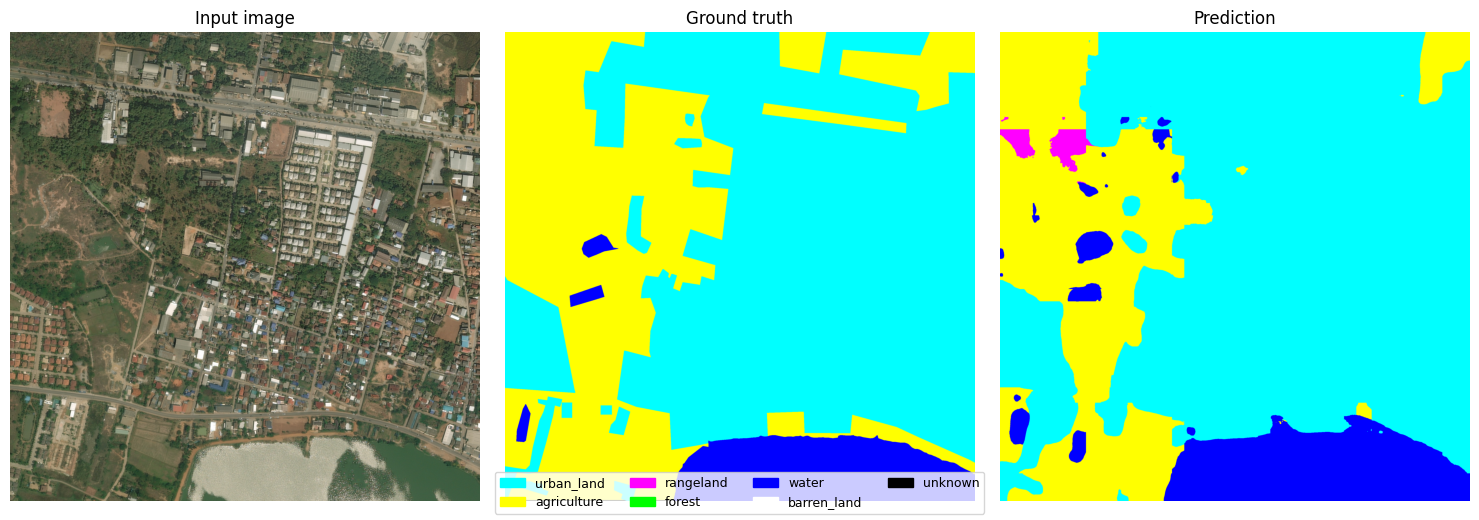

Saved → /kaggle/working/outputs/sample_prediction.png


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from PIL import Image
from pathlib import Path
import sys, torch
sys.path.insert(0, '/kaggle/working/code')
from task1_crop.inference import load_model, predict_full_image, CLASS_NAMES, NUM_CLASSES
from task1_crop.utils.preprocessing import decode_mask

DATA_DIR = '/kaggle/input/datasets/balraj98/deepglobe-land-cover-classification-dataset'
CKPT     = '/kaggle/input/models/manishsabnis/deepglobe-land-cover-best/pytorch/default/1/best.pt'

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model  = load_model(CKPT, device)

img_path  = sorted(Path(f'{DATA_DIR}/train').glob('*_sat.jpg'))[12]
mask_path = str(img_path).replace('_sat.jpg', '_mask.png')

image = np.array(Image.open(img_path).convert('RGB'))
gt    = decode_mask(mask_path)
pred, _ = predict_full_image(model, image, device)

COLORS = ['#00FFFF','#FFFF00','#FF00FF','#00FF00','#0000FF','#FFFFFF','#000000']

def colorize(mask):
    h, w = mask.shape
    rgb = np.zeros((h, w, 3), dtype=np.uint8)
    for i, c in enumerate(COLORS):
        r,g,b = int(c[1:3],16),int(c[3:5],16),int(c[5:7],16)
        rgb[mask==i] = [r,g,b]
    return rgb

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(image);               axes[0].set_title('Input image')
axes[1].imshow(colorize(gt));        axes[1].set_title('Ground truth')
axes[2].imshow(colorize(pred));      axes[2].set_title('Prediction')
for ax in axes: ax.axis('off')

patches = [mpatches.Patch(color=COLORS[i], label=CLASS_NAMES[i])
           for i in range(NUM_CLASSES)]
fig.legend(handles=patches, loc='lower center', ncol=4, fontsize=9)
plt.tight_layout()
plt.savefig('/kaggle/working/outputs/sample_prediction.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → /kaggle/working/outputs/sample_prediction.png')